# IMT 573 - Problem Set 8 - Prediction

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

5. Partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are *strongly* encouraged to attempt each question and document their reasoning process even if they cannot find the correct answer. 

6. After completing the assignment, ensure that your code can run from start to finish without issue. Restart the kernal and run all cells to double check.

Name: Emma Harding

Collaborators: 

For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In this problem set, we will aim to build a model to explain the factors associated with a person having a heart attack.  Thereafter we also look at the predicted values and compute accuracy. We will use a dataset `heart.csv` avaialable from https://archive.ics.uci.edu/dataset/45/heart+disease, which contains health information of each person (these are the predictors) and whether or not the person had a heart attack before (the binary outcome variable). You can download the data `heart.csv` from Canvas. 

The variables are (as described on the webpage):

- age: age of the patient
- sex: sex of the patient (1 = male; 0 = female)
- cp: chest pain type chest pain type (0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3: asymptomatic
- trestbps: resting blood pressure (in mm Hg)
- chol: cholestoral in mg/dl fetched via BMI sensor
- fbs: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- restecg: resting electrocardiographic results (0 normal; 1 = having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV); 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria.)
- thalachh: maximum heart rate achieved
- exang: exercise induced angina (1 = yes; 0 = no)
- oldpeak: ST depression induced by exercise relative to rest
- slope:the slope of the peak exercise ST segment ( 0= upsloping; 1= flat; 2 = downsloping )
- ca: number of major vessels (range : 0-3)
- thal (Thalassemias):  0 = error (in the original dataset 0 maps to NaN's); 1 = fixed defect ; 2 = normal; 3 = reversable defect

- target: 0 = no disease, 1 = disease


### Problem 1: Logistic Regression

Points: 10

As described above, our primary aim in this assignment is to build a model to predct heart attack status -- whether a person had a heart attack or not based on other health information. 

#### (a) Load the data

Load data.  The data should contain 303 rows, and 11 columns. Do some basic checks.  Andwer these questions:
- Do we have any missing values? Are you concerns about missing data?
- What are the data types? Do these make sense for the variables?
- What are ranges of numeric variables, and possible values of categorical variables?  
- What is the rate of heart attacks among these patients?
  
Compare the values with the documentation and comment what do you see.

In [2]:
#import data
df = pd.read_csv("heart.csv")

In [3]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.shape

(303, 14)

In [8]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [9]:
print(df.max())
print(df.min())

age          77.0
sex           1.0
cp            3.0
trestbps    200.0
chol        564.0
fbs           1.0
restecg       2.0
thalach     202.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0
dtype: float64
age          29.0
sex           0.0
cp            0.0
trestbps     94.0
chol        126.0
fbs           0.0
restecg       0.0
thalach      71.0
exang         0.0
oldpeak       0.0
slope         0.0
ca            0.0
thal          0.0
target        0.0
dtype: float64


In [10]:
# Find the range of the data
ranges = df.max() - df.min()
print(ranges)

age          48.0
sex           1.0
cp            3.0
trestbps    106.0
chol        438.0
fbs           1.0
restecg       2.0
thalach     131.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0
dtype: float64


In [11]:
#create a finter to show how may heart attacks there are
df_filtered = df[df["target"] == 1]
print(df_filtered.count)

<bound method DataFrame.count of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
160   56    1   1       120   240    0        1      169      0      0.0   
161   55    0   1       132   342    0        1      166      0      1.2   
162   41    1   1       120   157    0        1      182      0      0.0   
163   38    1   2       138   175    0        1      173      0      0.0   
164   38    1   2       138   175    0        1      173      0      0.0   

     slope  ca  thal  target  
0        0   0     1   

Source:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.filter.html

### Do we have any missing values? Are you concerns about missing data?
There doesn't appear to be missing data.

### What are the data types? Do these make sense for the variables?
The data types are int64 and float64. These make sense but it makes more sense if they're all int64.

### What are ranges of numeric variables, and possible values of categorical variables?
The ranges are:

age          48.0
sex           1.0
cp            3.0
trestbps    106.0
chol        438.0
fbs           1.0
restecg       2.0
thalach     131.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0

Possible values occur within the min and max for each column as well as outside of the min and the max because this dataset isn't all inclusive

### What is the rate of heart attacks among these patients?
There are 165 heart attacks

#### (b) Logistic regression model

Fit a logistic regression model with all the explanatory variables.  Do not forget to convert the categorical ones to categories!

In each case also comment on statistical significance of the results. (Hint : https://www.statsmodels.org/stable/discretemod.html )

In [20]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_label,sex_label
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,Heart Attack,Male
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,Heart Attack,Male
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,Heart Attack,Female
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,Heart Attack,Male
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,Heart Attack,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0,No Heart Attack,Female
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0,No Heart Attack,Male
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0,No Heart Attack,Male
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0,No Heart Attack,Male


In [12]:
#logistic regression model
X = df[["age","trestbps","chol","thalach","oldpeak","sex","cp","fbs","restecg","exang","slope","ca","thal"]]
X = sm.add_constant(X)   
y = df["target"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.348904
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  303
Model:                          Logit   Df Residuals:                      289
Method:                           MLE   Df Model:                           13
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.4937
Time:                        19:13:08   Log-Likelihood:                -105.72
converged:                       True   LL-Null:                       -208.82
Covariance Type:            nonrobust   LLR p-value:                 7.262e-37
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4505      2.571      1.342      0.180      -1.590       8.490
age           -0.0049      0.

Sources:https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

I used this source for documentation

I also used copilot for debugging

#### (c) Data Cleaning

You probably noticed that all the above variables are coded as numbers. However, not all of these are in fact of numeric (interval, ratio) measure type. Which variables above are inherently non-numeric (nominal or ordinal)? Fix any issues.

Inherently non numeric values include sex, heart attack or no heart attack, excercise induced angina, chest pain type, and Thalassemias.
There are no issues with these variables since they are all currently numeric in the dataframe.

Run EDA(Exploratory Data Analysis) to answer at least 2 questions listd below:
- How is age related to probability of heart attack?
- Are men or women more likely to have heart attack?   
- Is higher blood pressure (`trtbps`) associated with more heart attacks?
- How much more likely is heart attack for someone who has chest pain (`cp type 1`) compared to someone who has chest pain type 3?
- What is the heart attack distribution based on different (`restecg`) categories? 

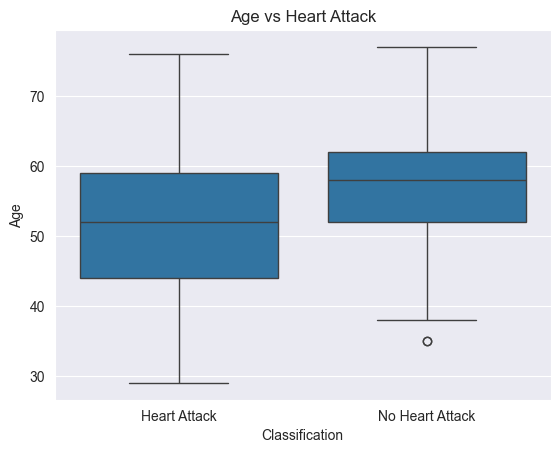

In [13]:
#plot showing how age is related o pobability of heart attack
df["target_label"] = df["target"].replace({0: "No Heart Attack", 1: "Heart Attack"})
sns.boxplot(x="target_label", y="age", data=df)
plt.title("Age vs Heart Attack")
plt.ylabel("Age")
plt.xlabel("Classification")
plt.show()

sex
0    0.750000
1    0.449275
Name: target, dtype: float64


Text(0.5, 0, 'Sex')

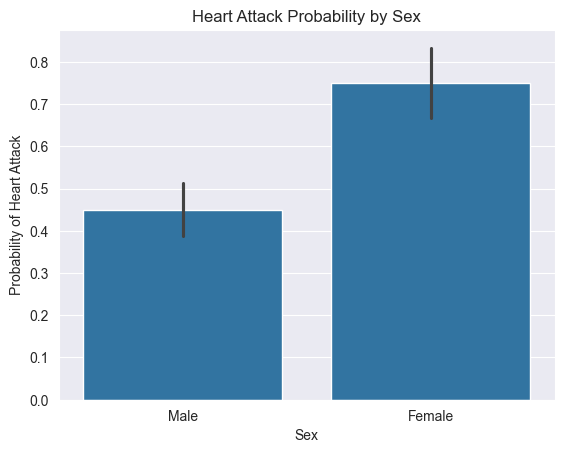

In [14]:
#plot showing heart attack probability by sex
df["sex_label"] = df["sex"].replace({0: "Female", 1: "Male"})
print(df.groupby("sex")["target"].mean())

sns.barplot(x="sex_label", y="target", data=df, estimator=lambda x: sum(x)/len(x))
plt.title("Heart Attack Probability by Sex")
plt.ylabel("Probability of Heart Attack")
plt.xlabel("Sex")

### Problem 2: Prediction

The last task is to split the dataset into a training (80% of the dataset) set and a testing (20% of the dataset) set. 

Run a logistic regression and another classification model (based on your own preference).  (Hint: Try scikit learn https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html )

Compute the confusion matrix based on the 2 models. Discuss what you find.

In [15]:
#find how much of the dataset is the training and how much is the testing sample
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 242
Testing samples: 61


In [16]:
# Initialize and fit the model & display model parameters
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
print("Coefficients:", log_reg.coef_)
print("Intercept:", log_reg.intercept_)

# Evaluate model performance
y_pred = log_reg.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Coefficients: [[ 0.06765247  0.00644228 -0.01179247 -0.00184035  0.02590678 -0.62653158
  -1.29603902  0.82392123  0.02247806  0.58704746 -0.88579497  0.6648983
  -0.73722152 -0.9001012 ]]
Intercept: [0.06768561]
Confusion Matrix:
[[25  4]
 [ 4 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



Confusion Matrix:
[[25  4]
[ 4 28]]


25 true negatives
4 false positives
28 true positives
4 false positives

The model is balanced because it correctly predicts most negatives and positives with 87% accuracy I don't want my model to be overfit to my data.

My source for the two code cells above is the logistic_regression_iris_example from class

### Problem 3: Reflection

What concerns do you have about this data and the analysis above? How might data on heart attack status and a model like the one you fit above be used in the real world?

My concerns about this dataset is it's really small comprared to other data sets we've worked with for homework problems so I wouldn't feel comfortable using this dataset to make predictions about the general population unless I added in more data.

I used copilot for debugging throughout but found the iris logistic regression example from class to be very helpful in running the tests